# gradpulse on a real device calibration (Rigetti Cepheus-1-108Q)

Load measured T1/T2 + native-CZ fidelity from a standardized Braket
calibration JSON, optimize a CZ against that pair's coherence, and compare.
The loader is device-agnostic -- point `CAL` at any device's export.

In [1]:
from pathlib import Path
import gradpulse as gp
from gradpulse import ParametricCouplerProfile, ParametricCZOptimizer
from gradpulse import viz

CAL = Path('../data/rigetti_cepheus_calibration.json')  # bundled real device data
PAIR = (46, 47)
profile = ParametricCouplerProfile.from_braket_calibration(
    str(CAL), PAIR,
    freq_ghz_q1=4.6838, freq_ghz_q2=4.7788,  # drive freqs from the device frames
)
print('measured T1/T2 (us):', profile.t1_ns_q1/1e3, profile.t2_ns_q1/1e3)
print('device native CZ fidelity:', profile.native_cz_fidelity)
for n in profile.notes: print('note:', n)

measured T1/T2 (us): 4.508812460279898 5.452849946019356
device native CZ fidelity: 0.9918799912127174
note: Loaded measured T1/T2 and native CZ 0.9919 for qubits (46, 47) from Braket calibration 'rigetti_cepheus_calibration.json'.


## Optimize against this pair's measured coherence

 [gradpulse] Starting parametric-CZ GRAPE (4 seeds, 150 slices @ 1.0 ns = 150.0 ns gate, 200 iters, loss=F_proc, lr=0.0100/cosine(min=0.05), drag_order=0)...


    Step 0000 | Max Fid: 0.2816874  | Mean: 0.2676468  | lr: 0.00100


    Step 0025 | Max Fid: 0.8294257  | Mean: 0.7955929  | lr: 0.00985


    Step 0050 | Max Fid: 0.9513619  | Mean: 0.9445921  | lr: 0.00900


    Step 0075 | Max Fid: 0.9600605  | Mean: 0.9594160  | lr: 0.00751


...

    Step 0125 | Max Fid: 0.9624713  | Mean: 0.9614129  | lr: 0.00371


    Step 0150 | Max Fid: 0.9626871  | Mean: 0.9616103  | lr: 0.00203


    Step 0175 | Max Fid: 0.9627786  | Mean: 0.9617009  | lr: 0.00090


    Step 0199 | Max Fid: 0.9628189  | Mean: 0.9617403  | lr: 0.00050

 [gradpulse] Adam plateau: F_proc=0.9628189. Switching to L-BFGS polish (50 iters)...


    L-BFGS:  F_proc=0.9645117  (+0.00169)
optimized CZ:  F_proc=0.96451  F_avg=0.97161
device native CZ (interleaved RB): 0.99188


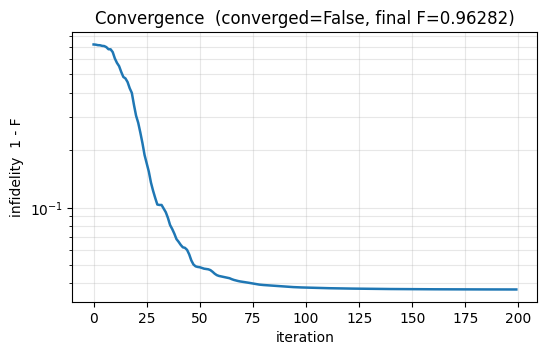

In [2]:
opt = ParametricCZOptimizer(profile, bandwidth_mhz=80.0)
r = opt.optimize_multi_seed(n_seeds=4, iterations=200, n_slices=150, dt_ns=1.0)
f_proc = r['best_fidelity']; f_avg = (4*f_proc + 1)/5
print(f'optimized CZ:  F_proc={f_proc:.5f}  F_avg={f_avg:.5f}')
print(f'device native CZ (interleaved RB): {profile.native_cz_fidelity:.5f}')
viz.plot_convergence(r);

## How good is that agreement, really?
One pair is an anecdote. The honest test is the **whole device**: across all 160
Cepheus pairs this same coherence floor is a *one-sided lower bound* on the measured
CZ error (median 0.66×), and where a gate is coherence-limited it saturates the
measurement to within its own RB error bar (median 0.60σ, all within 2σ). That
fleet-wide result (the project's flagship) is walked through in
[`03_hardware_validation.ipynb`](03_hardware_validation.ipynb).

Two caveats remain on *this* single-pair number, and neither is papered over: ours is
a *simulation* on the device's measured coherence, not a hardware RB measurement; and
Braket exposes only idling-point T1/T2, so the floor is a lower bound on the
gate-effective error, not an equality. Cross-check any optimized pulse against an
independent QuTiP integrator with `python -m gradpulse.validate --pulse <pulse.json>`.

## Export to hardware
Once you have re-optimized against this device's calibration, export the
**complete** pulse (in-phase **plus** the derived DRAG quadrature) for a
pulse-level backend:
- **Amazon Braket**: `gradpulse.braket_bridge` → a `braket.pulse.PulseSequence` and a priced interleaved-RB run.
- **Vendor-neutral**: `gradpulse.openpulse_export.to_openpulse_program(opt.iq_waveform(r['best_raw_param']), dt_ns=1.0)` → OpenQASM 3 / OpenPulse 3.0 text, re-parse-verified offline with `verify_openpulse_roundtrip(...)`.

Both build everything up to `device.run()`: the one step that needs a QPU and credentials.